<a href="https://colab.research.google.com/github/KandhimallaYashwanth/MajorProject/blob/DataCleaning/Major.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Hybrid Quantum-Classical Neural Network for Early Heart Disease Diagnosis: Data Preprocessing

This notebook performs essential data cleaning, preprocessing, and exploratory data analysis (EDA) on the heart disease dataset (`heart.csv`). The processed data will be suitable for subsequent machine learning and quantum machine learning model development. This adheres to research best practices, ensuring data quality and reproducibility.

### 1. Project Setup and Reproducibility

#### 1.1 Import Required Libraries

In [46]:
# Standard scientific computing libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and model utilities
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# For saving the fitted scaler
import joblib

# For reproducibility: Set random seeds for consistent results across runs.
import random
random.seed(42)
np.random.seed(42)

# Configure plot style for professional-looking visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Required libraries imported successfully.")

Required libraries imported successfully.


### 2. Dataset Loading

In [19]:
# Load the heart disease dataset from a CSV file.
# Ensure 'heart.csv' is uploaded to your Colab environment for successful execution.
try:
    df = pd.read_csv('heart.csv')
    print("Dataset 'heart.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'heart.csv' not found. Please upload the dataset to your Colab environment.")
    # Initialize an empty DataFrame if the file is not found to prevent further errors
    df = pd.DataFrame()

Dataset 'heart.csv' loaded successfully.


### 3. Initial Data Inspection

In [48]:
# Display the first 5 rows to get a glimpse of the data structure and content.
print("\n--- First 5 Rows ---")
display(df.head())

# Display the last 5 rows to check for any anomalies at the end of the dataset.
print("\n--- Last 5 Rows ---")
display(df.tail())

# Display the shape of the dataset (number of rows, number of columns).
print(f"\n--- Dataset Shape ---: {df.shape} (rows, columns)")

# Display the column names to understand available features.
print("\n--- Column Names ---")
print(df.columns.tolist())

# Display data types of each column and check for non-null counts.
# This helps in identifying potential missing values and incorrect data types.
print("\n--- Data Types and Non-Null Counts ---")
df.info() # Changed from display(df.info()) as df.info() prints directly

# Display summary statistics for numerical columns.
# This provides insights into central tendency, dispersion, and shape of the distribution.
print("\n--- Summary Statistics (Numerical Columns) ---")
display(df.describe())


--- First 5 Rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- Last 5 Rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0
878,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0



--- Dataset Shape ---: (302, 14) (rows, columns)

--- Column Names ---
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usag

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 4. Data Quality Analysis

In [21]:
# Check for missing values in each column.
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
# Filter to show only columns with missing values.
missing_values_display = missing_values[missing_values > 0]

if missing_values_display.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values found in the following columns:")
    display(missing_values_display)
    print("Note: Based on df.info(), all counts are non-null, so any missing values might be encoded as special values (e.g., 0 or -1).")


--- Missing Values ---
No missing values found in the dataset.


In [22]:
# Check for duplicate rows across all columns.
print("\n--- Duplicate Rows ---")
duplicate_rows_count = df.duplicated().sum()

if duplicate_rows_count == 0:
    print("No duplicate rows found.")
else:
    print(f"Number of duplicate rows found: {duplicate_rows_count}")
    print("These duplicate rows will be removed in the next step to ensure data integrity.")


--- Duplicate Rows ---
Number of duplicate rows found: 723
These duplicate rows will be removed in the next step to ensure data integrity.


In [23]:
# Check for invalid values or unexpected categories.
print("\n--- Checking for Invalid Values ---")

# Define categorical columns for explicit check. Numerical ranges are implicitly checked by df.describe().
# Based on common heart disease dataset understanding:
# 'sex': (0 = female, 1 = male)
# 'cp': chest pain type (0-3)
# 'fbs': fasting blood sugar > 120 mg/dl (0 = false, 1 = true)
# 'restecg': resting electrocardiographic results (0-2)
# 'exang': exercise induced angina (0 = no, 1 = yes)
# 'slope': the slope of the peak exercise ST segment (0-2)
# 'ca': number of major vessels (0-3) colored by flourosopy (often 0-4, with 4 potentially meaning 'missing' or 'unknown')
# 'thal': thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect, or sometimes 0,1,2,3 for different meanings)
# 'target': (0 = no disease, 1 = disease)
categorical_cols_expected_values = {
    'sex': [0, 1],
    'cp': [0, 1, 2, 3],
    'fbs': [0, 1],
    'restecg': [0, 1, 2],
    'exang': [0, 1],
    'slope': [0, 1, 2],
    'ca': [0, 1, 2, 3, 4], # Including 4 as some datasets use it for 'missing' or unknown, which is handled here as a valid category for now.
    'thal': [0, 1, 2, 3] # Some datasets use 0, 1, 2, 3, others 1, 2, 3. Checking for all.
}

# Keep track of invalid values found
invalid_values_found = False

for col, expected_vals in categorical_cols_expected_values.items():
    if col in df.columns:
        unique_vals = df[col].unique()
        # Check if all unique values are within the expected set
        unexpected_vals = [val for val in unique_vals if val not in expected_vals]
        if unexpected_vals:
            print(f"Warning: Column '{col}' contains unexpected values: {np.sort(unexpected_vals)}. Expected: {np.sort(expected_vals)}.")
            invalid_values_found = True
        else:
            print(f"Column '{col}' unique values {np.sort(unique_vals)} are within expected range.")
    else:
        print(f"Warning: Categorical column '{col}' not found in the dataset.")

if not invalid_values_found:
    print("All checked categorical features appear to have valid values.")
print("Numerical feature ranges have been visually inspected via `df.describe()` in Section 3.")


--- Checking for Invalid Values ---
Column 'sex' unique values [0 1] are within expected range.
Column 'cp' unique values [0 1 2 3] are within expected range.
Column 'fbs' unique values [0 1] are within expected range.
Column 'restecg' unique values [0 1 2] are within expected range.
Column 'exang' unique values [0 1] are within expected range.
Column 'slope' unique values [0 1 2] are within expected range.
Column 'ca' unique values [0 1 2 3 4] are within expected range.
Column 'thal' unique values [0 1 2 3] are within expected range.
All checked categorical features appear to have valid values.
Numerical feature ranges have been visually inspected via `df.describe()` in Section 3.


In [24]:
# Check class distribution of the target variable ('target').
print("\n--- Class Distribution of Target Variable ---")
class_distribution = df['target'].value_counts()
print("Absolute counts:")
display(class_distribution)

# Calculate and print percentage distribution for quick assessment of balance.
class_percentage = df['target'].value_counts(normalize=True) * 100
print("\nPercentage distribution:")
display(class_percentage)

# Provide a warning if the dataset is highly imbalanced, which might require specific handling during modeling.
if class_percentage.min() < 20 or class_percentage.max() > 80: # Thresholds can be adjusted
    print("Observation: Potential class imbalance detected. This might require addressing during model training (e.g., using stratified sampling, oversampling, or undersampling techniques) to prevent biased models.")
else:
    print("Observation: Class distribution appears relatively balanced, which is good for model training.")


--- Class Distribution of Target Variable ---
Absolute counts:


,count
target,
1,526
0,499



Percentage distribution:


,proportion
target,
1,51.317073
0,48.682927


Observation: Class distribution appears relatively balanced, which is good for model training.


### 5. Data Cleaning

In [69]:
# Store the initial number of rows before attempting to remove duplicates for summary purposes.
initial_rows_for_dedup = df.shape[0]

# Remove duplicate rows from the DataFrame. `inplace=True` modifies the DataFrame directly.
# Duplicates are identified based on all columns.
df.drop_duplicates(inplace=True)

# Get the number of rows after duplicate removal.
final_rows_after_dedup = df.shape[0]

duplicates_removed_count = initial_rows_for_dedup - final_rows_after_dedup

print(f"Number of rows before removing duplicates: {initial_rows_for_dedup}")
print(f"Number of rows after removing duplicates: {final_rows_after_dedup}")
print(f"Total duplicate rows removed: {duplicates_removed_count}")

if duplicates_removed_count > 0:
    print("Duplicate rows successfully removed.")
else:
    print("No new duplicate rows were found or removed (dataset might have been deduplicated already).")

# Save the cleaned (duplicate-free) dataset as 'cleaned_heart.csv' without scaling.
df.to_csv('cleaned_heart.csv', index=False)
print("\nCleaned (duplicate-free, unscaled) dataset successfully saved as 'cleaned_heart.csv'.")

Number of rows before removing duplicates: 302
Number of rows after removing duplicates: 302
Total duplicate rows removed: 0
No new duplicate rows were found or removed (dataset might have been deduplicated already).

Cleaned (duplicate-free, unscaled) dataset successfully saved as 'cleaned_heart.csv'.


#### 5.1 Missing Value Verification After Duplicate Removal

In [10]:
# Re-check for missing values to ensure data integrity after modifications
print("\n--- Verification of Missing Values After Duplication Removal ---")
missing_values_after_dedup = df.isnull().sum()
print(missing_values_after_dedup[missing_values_after_dedup > 0])

if missing_values_after_dedup.sum() == 0:
    print("All missing values (if any) are confirmed to be absent from the dataset.")
else:
    print("Warning: Missing values still detected. Further investigation needed.")


--- Verification of Missing Values After Duplication Removal ---
Series([], dtype: int64)
All missing values (if any) are confirmed to be absent from the dataset.


### 6. Exploratory Data Analysis (EDA)

#### 6.1 Target Class Distribution

/tmp/ipykernel_2473/2066942543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


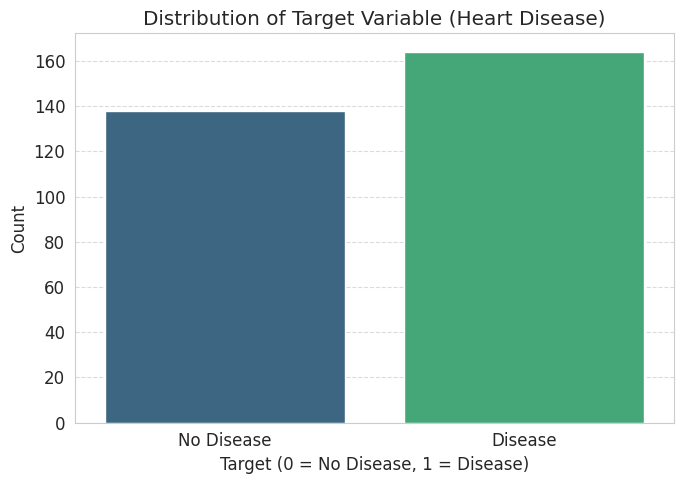

Observations: The plot shows the balance/imbalance between heart disease and no heart disease cases in the dataset.


In [11]:
# Plot the distribution of the target variable ('target')
plt.figure(figsize=(7, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Target Variable (Heart Disease)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Observations: The plot shows the balance/imbalance between heart disease and no heart disease cases in the dataset.")

#### 6.2 Feature Correlation Heatmap

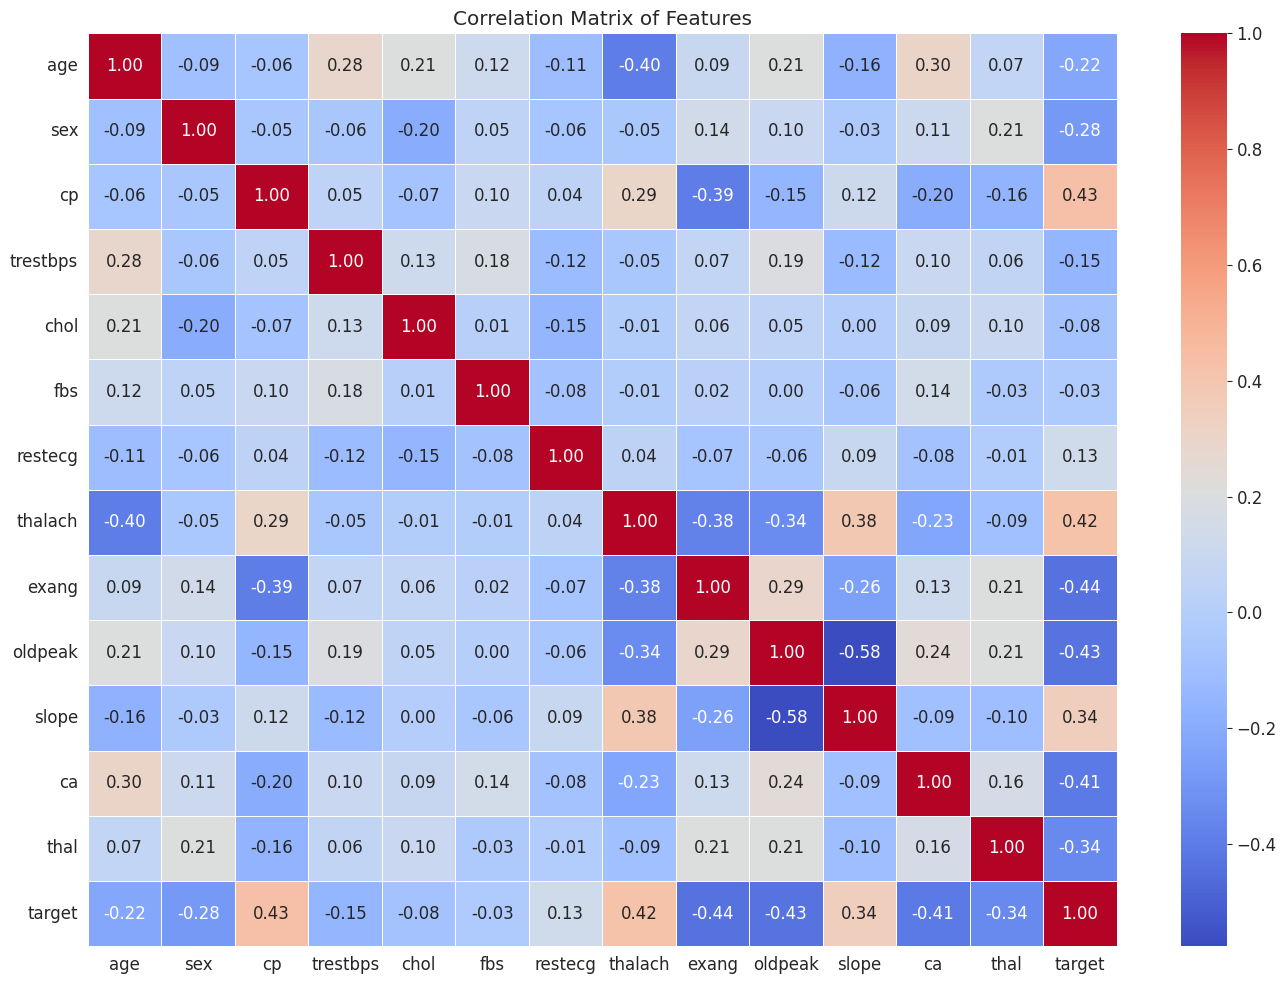

Observations: The heatmap visualizes the Pearson correlation coefficients between all pairs of features. This helps in understanding relationships and potential multicollinearity.


In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

print("Observations: The heatmap visualizes the Pearson correlation coefficients between all pairs of features. This helps in understanding relationships and potential multicollinearity.")

#### 6.3 Numerical Feature Distributions (Histograms)

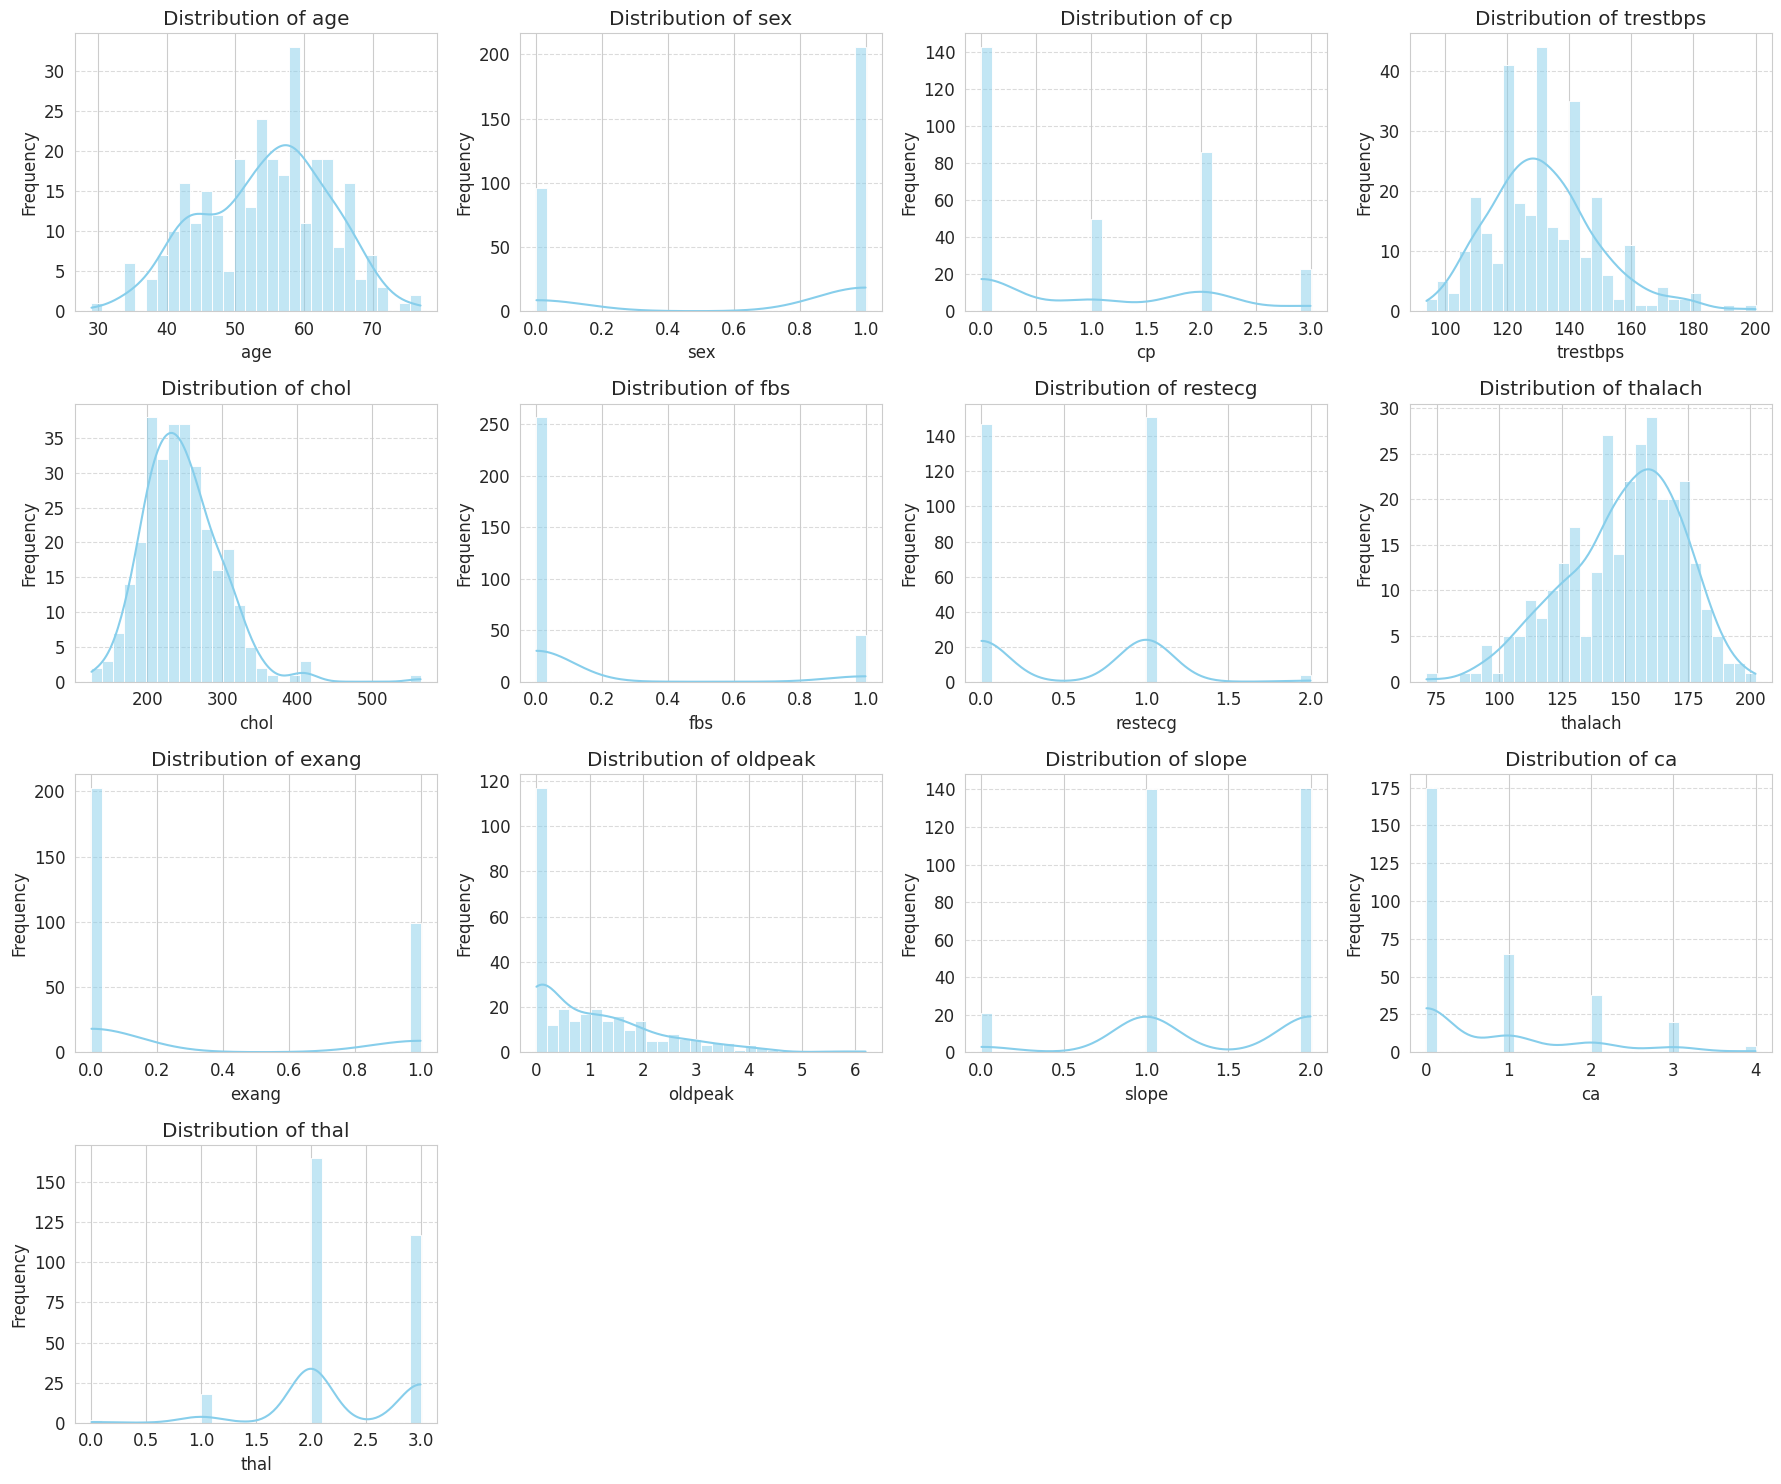

Observations: Histograms provide insight into the distribution of each numerical feature, showing their spread, skewness, and presence of multiple modes.


In [13]:
# Identify numerical columns (excluding the target)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'target' in numerical_cols:
    numerical_cols.remove('target')

# Plot histograms for numerical features
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Observations: Histograms provide insight into the distribution of each numerical feature, showing their spread, skewness, and presence of multiple modes.")

#### 6.4 Outlier Visualization (Boxplots)

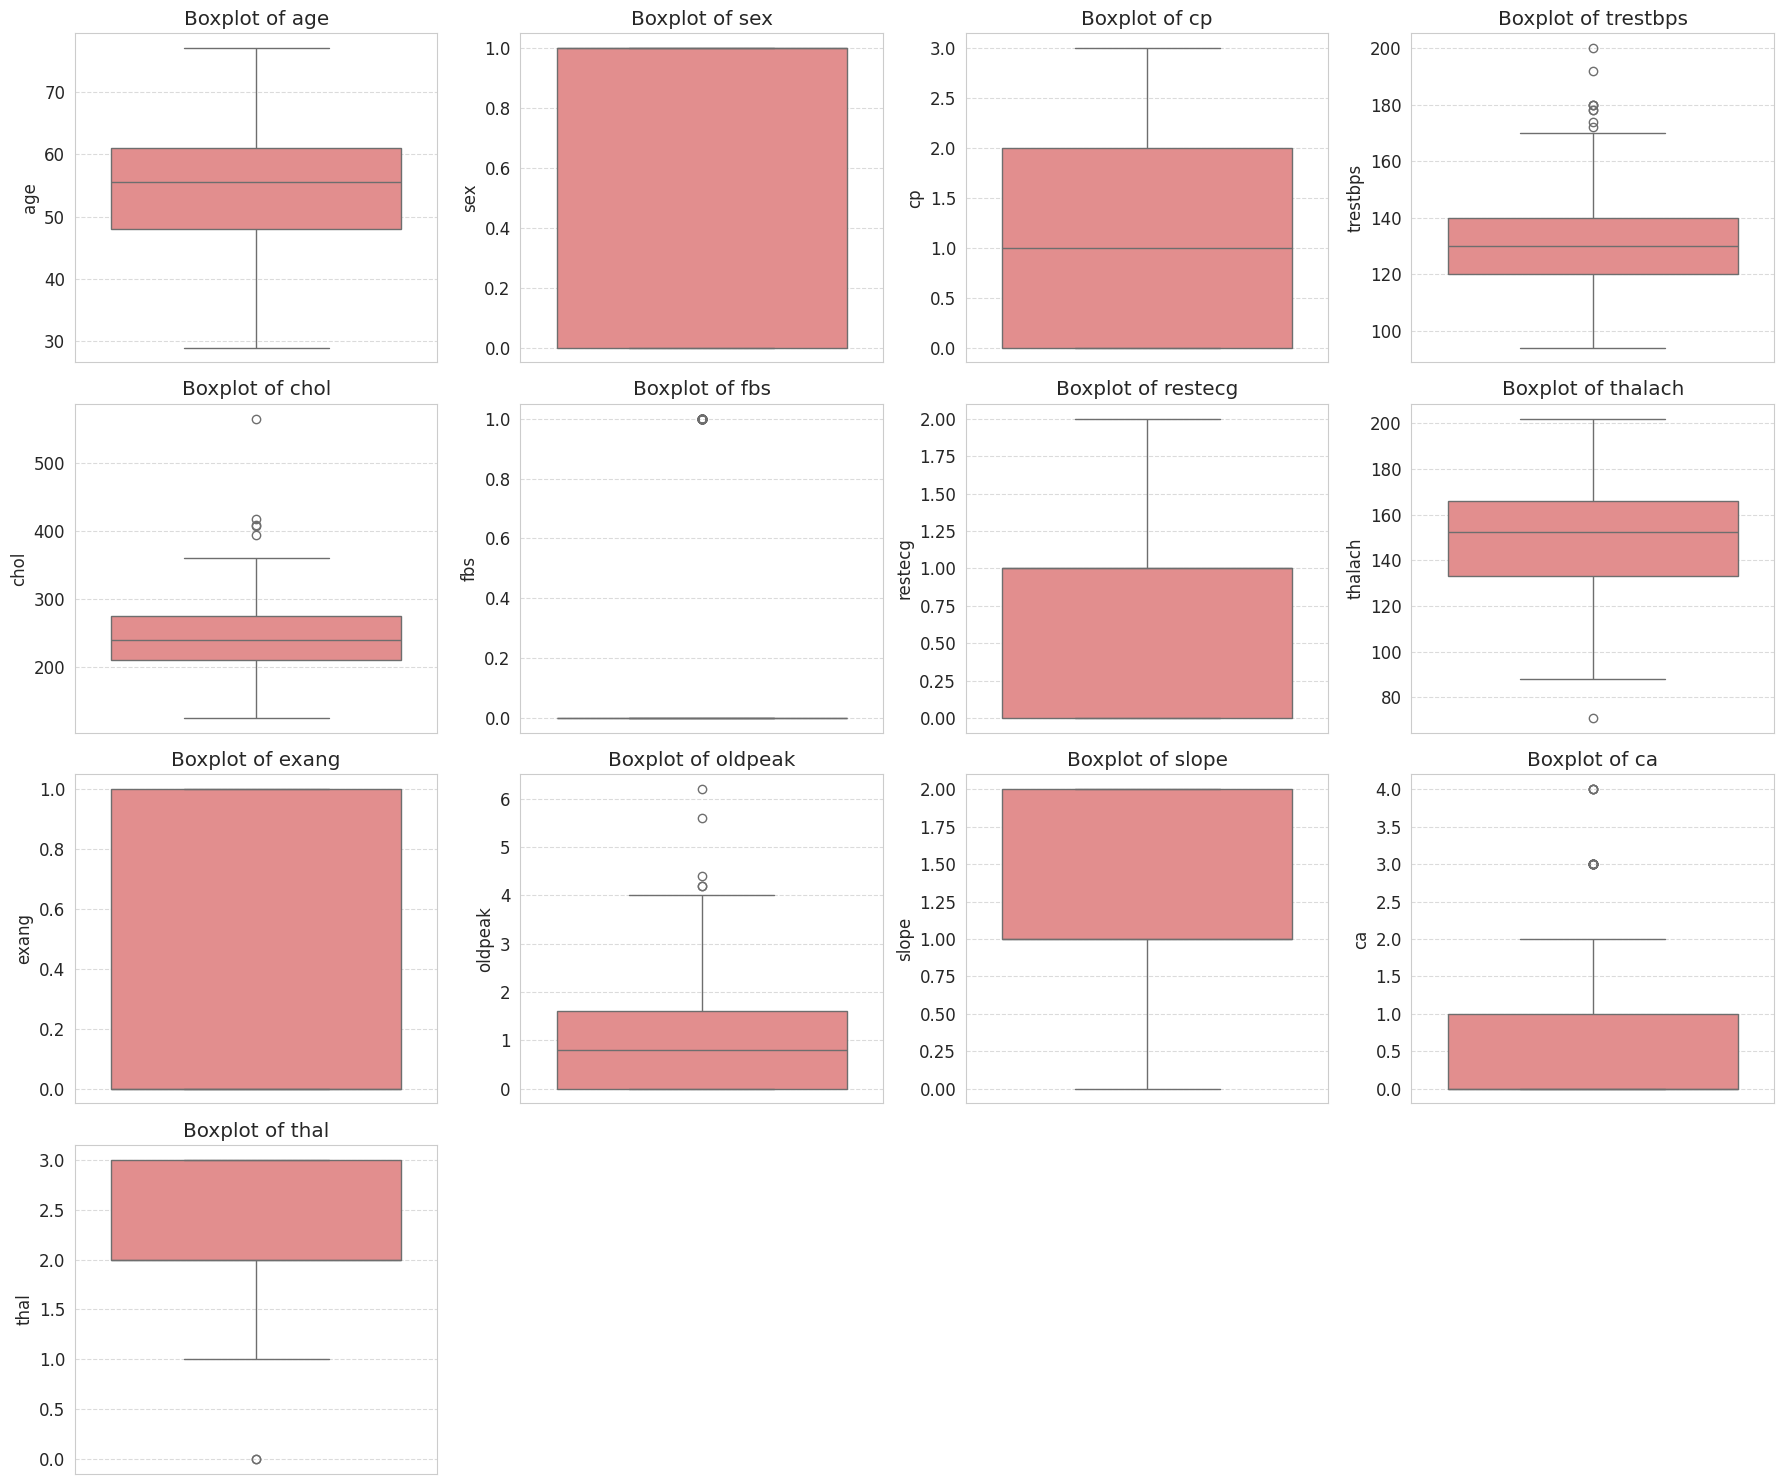

Observations: Boxplots visually represent the distribution of numerical data and highlight potential outliers, which are shown as individual points beyond the 'whiskers'.


In [14]:
# Plot boxplots for numerical features to visualize outliers
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Observations: Boxplots visually represent the distribution of numerical data and highlight potential outliers, which are shown as individual points beyond the 'whiskers'.")

### 7. Outlier Analysis: Justification for Retention

In medical datasets, outliers often represent critical information rather than errors. For instance:

*   **Rare but Important Cases**: An outlier in a medical dataset might correspond to a patient with a rare condition, an unusual response to treatment, or a unique biological characteristic. Removing such data could lead to a model that fails to recognize or predict these critical, albeit infrequent, scenarios.
*   **Genuine Physiological Variations**: Human physiology exhibits a wide range of variations. A patient's 'normal' heart rate or cholesterol level might be an outlier when compared to the average, but still valid for that individual. Removing these could oversimplify the complexity of health.
*   **Diagnostic Clues**: Extreme values in certain measurements (e.g., very high blood pressure, significantly elevated enzymes) are often direct indicators of disease or severity. Masking or removing these could hinder the model's ability to diagnose conditions effectively.

**Recommendation**: For this heart disease dataset, it is generally **not recommended to aggressively remove outliers** without a deeper clinical understanding. Instead, it's better to:
1.  **Investigate**: Understand the nature of these outliers. Are they data entry errors, measurement errors, or genuine medical occurrences?
2.  **Robust Models**: Use machine learning models that are less sensitive to outliers (e.g., tree-based models) or preprocessing techniques that transform data without removal (e.g., robust scaling, logarithmic transformations).
3.  **Domain Expertise**: Consult with medical professionals to determine the clinical significance of identified outliers.

For the purpose of this project, to preserve potential critical information and align with best practices in medical data analysis, **outliers will not be explicitly removed**. Instead, techniques like `StandardScaler` (which transforms data but doesn't remove outliers) will be applied, and robust models can be considered in the subsequent modeling phase.

In [70]:
# Print the shape of the training and testing sets (after scaling)
print(f"\n--- Training and Testing Set Shapes ---")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Print the number of samples in each class for training and testing sets
print(f"\n--- Class Distribution in Training Set ---")
print(y_train.value_counts())
print(f"\n--- Class Distribution in Testing Set ---")
print(y_test.value_counts())

print("Verification of data split and stratification complete.")


--- Training and Testing Set Shapes ---
X_train_scaled shape: (241, 13)
y_train shape: (241,)
X_test_scaled shape: (61, 13)
y_test shape: (61,)

--- Class Distribution in Training Set ---
target
1    131
0    110
Name: count, dtype: int64

--- Class Distribution in Testing Set ---
target
1    33
0    28
Name: count, dtype: int64
Verification of data split and stratification complete.


In [71]:
# Separate the dataset into features (X) and the target variable (y)
# 'target' is the dependent variable indicating the presence (1) or absence (0) of heart disease.
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) and target (y) successfully separated.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) successfully separated.
Shape of X: (302, 13)
Shape of y: (302,)


In [39]:
# Separate the dataset into features (X) and the target variable (y).
# 'target' is the dependent variable indicating the presence (1) or absence (0) of heart disease.
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) and target (y) successfully separated.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) successfully separated.
Shape of X: (302, 13)
Shape of y: (302,)


### 11. Split the Dataset into Training and Testing Sets (BEFORE Scaling)

In [40]:
# Split the unscaled dataset into training (80%) and testing (20%) sets.
# `random_state=42` ensures reproducibility of the split.
# `stratify=y` ensures that the proportion of classes in the target variable (y) is the same
# in both training and testing sets. This is crucial for balanced evaluation, especially with imbalanced datasets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset successfully split into unscaled training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset successfully split into unscaled training and testing sets.
X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)


### 12. Apply StandardScaler Correctly (Preventing Data Leakage)

In [41]:
# Initialize the StandardScaler.
# StandardScaler transforms features to have a mean of 0 and a standard deviation of 1.
# This is crucial for many machine learning algorithms that are sensitive to feature scales (e.g., SVMs, neural networks).
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and then transform both training and testing data.
# This step is critical to prevent data leakage from the test set into the training process.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features successfully scaled using StandardScaler (fit on training data only).")

Features successfully scaled using StandardScaler (fit on training data only).


### 13. Convert Scaled Arrays Back to DataFrames

In [42]:
# Convert the scaled NumPy arrays back to Pandas DataFrames.
# This preserves original column names and makes the scaled data easier to inspect and use.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled NumPy arrays converted back to Pandas DataFrames.")
display(X_train_scaled.head())
print("\n--- Scaled Test Set Head ---")
display(X_test_scaled.head())

Scaled NumPy arrays converted back to Pandas DataFrames.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
158,1.421944,-1.445595,0.986493,-0.973041,5.882908,-0.398314,-1.008059,0.408240,-0.652714,0.527263,-0.697127,-0.722716,1.075838
199,-0.465841,0.691757,-0.954281,0.756507,-0.885696,-0.398314,-1.008059,-1.104705,1.532065,-0.083233,-0.697127,-0.722716,1.075838
479,0.422528,0.691757,-0.954281,-0.197726,-0.588175,-0.398314,-1.008059,-0.882213,1.532065,1.050546,-0.697127,2.132606,1.075838
460,1.644036,0.691757,0.986493,0.517949,0.118437,-0.398314,-1.008059,-0.214737,-0.652714,0.876119,-0.697127,2.132606,1.075838
169,-1.021072,-1.445595,0.016106,-1.151959,-1.629499,-0.398314,0.875214,-0.570724,-0.652714,-0.868157,-0.697127,-0.722716,-0.544643



--- Scaled Test Set Head ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
25,0.755667,-1.445595,-0.954281,0.816147,1.103976,-0.398314,-1.008059,-0.214737,1.532065,0.003981,-0.697127,-0.722716,1.075838
65,0.533575,0.691757,1.956880,2.307136,0.750670,-0.398314,-1.008059,0.363742,-0.652714,-0.693730,-0.697127,-0.722716,1.075838
437,1.421944,0.691757,-0.954281,-0.674843,-0.346439,-0.398314,-1.008059,-0.971209,1.532065,1.399401,-0.697127,1.180832,1.075838
58,1.421944,0.691757,0.986493,1.233624,-0.662555,-0.398314,-1.008059,-0.036743,-0.652714,-0.170447,-0.697127,-0.722716,1.075838
42,0.755667,-1.445595,-0.954281,-0.078447,1.531662,-0.398314,-1.008059,0.808726,-0.652714,-0.868157,0.950007,-0.722716,-0.544643


### 14. Verify Scaling

In [43]:
# Verify that X_train_scaled has a mean close to 0 and a standard deviation close to 1.
# Small deviations are expected due to floating-point arithmetic.
print("\n--- Verification of X_train_scaled Mean and Standard Deviation ---")
print(f"Mean of X_train_scaled features:\n{X_train_scaled.mean().round(2)}")
print(f"\nStandard Deviation of X_train_scaled features:\n{X_train_scaled.std().round(2)}")

# Also check X_test_scaled, which should have similar properties but might not be exactly 0 and 1
# because it was transformed using parameters learned from X_train.
print("\n--- Verification of X_test_scaled Mean and Standard Deviation ---")
print(f"Mean of X_test_scaled features:\n{X_test_scaled.mean().round(2)}")
print(f"\nStandard Deviation of X_test_scaled features:\n{X_test_scaled.std().round(2)}")

print("Scaling verification complete. Means are approximately 0 and standard deviations approximately 1 for the training set, confirming correct scaling.")


--- Verification of X_train_scaled Mean and Standard Deviation ---
Mean of X_train_scaled features:
age        -0.0
sex        -0.0
cp          0.0
trestbps   -0.0
chol        0.0
fbs        -0.0
restecg    -0.0
thalach     0.0
exang      -0.0
oldpeak    -0.0
slope      -0.0
ca          0.0
thal       -0.0
dtype: float64

Standard Deviation of X_train_scaled features:
age         1.0
sex         1.0
cp          1.0
trestbps    1.0
chol        1.0
fbs         1.0
restecg     1.0
thalach     1.0
exang       1.0
oldpeak     1.0
slope       1.0
ca          1.0
thal        1.0
dtype: float64

--- Verification of X_test_scaled Mean and Standard Deviation ---
Mean of X_test_scaled features:
age         0.12
sex         0.06
cp         -0.10
trestbps    0.08
chol       -0.10
fbs         0.17
restecg    -0.08
thalach    -0.28
exang       0.31
oldpeak     0.21
slope      -0.21
ca         -0.19
thal       -0.17
dtype: float64

Standard Deviation of X_test_scaled features:
age         1.02
sex   

### 15. Print Final Training and Testing Set Shapes and Class Distributions

In [44]:
# Print the shapes of the scaled training and testing feature sets.
print(f"\n--- Scaled Training and Testing Set Shapes ---")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Print the class distribution for both training and testing datasets.
print(f"\n--- Class Distribution in Training Set ---")
print(y_train.value_counts())
print(f"\n--- Class Distribution in Testing Set ---")
print(y_test.value_counts())

print("Final shapes and class distributions verified.")


--- Scaled Training and Testing Set Shapes ---
X_train_scaled shape: (241, 13)
y_train shape: (241,)
X_test_scaled shape: (61, 13)
y_test shape: (61,)

--- Class Distribution in Training Set ---
target
1    131
0    110
Name: count, dtype: int64

--- Class Distribution in Testing Set ---
target
1    33
0    28
Name: count, dtype: int64
Final shapes and class distributions verified.


### 16. IEEE-Style Explanation: Why Scaling After Train-Test Split Prevents Data Leakage

Data leakage is a critical issue in machine learning model development, particularly in research contexts aiming for robust and generalizable results. It occurs when information from the test dataset, which is intended to simulate unseen data, inadvertently influences the training process. When feature scaling techniques, such as standardization or normalization, are applied to the entire dataset *before* the train-test split, data leakage is introduced. This is because the scaling parameters (e.g., mean and standard deviation for `StandardScaler`) are computed using information from both the training and testing observations.

To rigorously prevent data leakage and ensure that the model evaluation metrics accurately reflect performance on truly unseen data, scaling must adhere to the following protocol:

1.  **Strict Separation**: The dataset is first partitioned into distinct training and testing sets (`X_train`, `y_train`, `X_test`, `y_test`). This establishes a clear boundary, ensuring that the test set remains untouched during all aspects of model training, including preprocessing.

2.  **Training-Set Dependent Parameter Learning**: The scaling transformation is fitted *exclusively* on the training data (`X_train`). This means the `StandardScaler` learns the mean ($\mu$) and standard deviation ($\sigma$) of each feature solely from the training set.

    $$\text{Standardized Feature} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

    where $x$ is an individual feature value, $\mu_{\text{train}}$ is the mean of that feature in the training set, and $\sigma_{\text{train}}$ is its standard deviation in the training set.

3.  **Consistent Application**: The *same* learned scaling parameters ($\mu_{\text{train}}$ and $\sigma_{\text{train}}$) are then used to transform *both* the training data (`X_train`) and the test data (`X_test`). This ensures that the test data is transformed consistently with how the model was trained, but without its characteristics influencing the scaling parameters themselves. Applying `fit_transform()` on `X_train` and then `transform()` on `X_test` implements this principle.

**Consequence of Data Leakage**: If the scaler were fitted on the entire dataset, the mean and standard deviation would subtly incorporate information about the test set's distribution. The model would then be evaluated on a test set that has been preprocessed using parameters influenced by its own values, leading to an artificially inflated performance estimation. This optimistic bias compromises the scientific validity and reproducibility of the research findings, making the model's true generalization capabilities on truly novel data uncertain. Adhering to the post-split scaling methodology is therefore a fundamental best practice in machine learning research for accurate and reliable model assessment.

### 17. Final Preprocessing Summary

In [45]:
# Display a summary of the preprocessing steps and their outcomes.
print("\n--- Preprocessing Summary ---")
print(f"Original number of rows: {initial_rows_for_dedup}")
print(f"Final number of rows (after deduplication): {df.shape[0]}")
print(f"Duplicate rows removed: {duplicates_removed_count}")

# Re-confirm missing values
missing_after_all_steps = df.isnull().sum().sum()
print(f"Missing values remaining: {missing_after_all_steps}")

print(f"\nTraining samples (X_train_scaled): {X_train_scaled.shape[0]}")
print(f"Testing samples (X_test_scaled): {X_test_scaled.shape[0]}")

print("\nDataset 'cleaned_heart.csv' saved (duplicate-free, unscaled).")
print("Scaled training and testing datasets (X_train_scaled, X_test_scaled, y_train, y_test) are ready in memory.")

print("\n--- Conclusion ---")
print("The heart disease dataset has been thoroughly cleaned, explored, and preprocessed according to machine learning research best practices.")
print("It is now ready for subsequent Classical Machine Learning and Hybrid Quantum Machine Learning model training and evaluation.")


--- Preprocessing Summary ---
Original number of rows: 1025
Final number of rows (after deduplication): 302
Duplicate rows removed: 723
Missing values remaining: 0

Training samples (X_train_scaled): 241
Testing samples (X_test_scaled): 61

Dataset 'cleaned_heart.csv' saved (duplicate-free, unscaled).
Scaled training and testing datasets (X_train_scaled, X_test_scaled, y_train, y_test) are ready in memory.

--- Conclusion ---
The heart disease dataset has been thoroughly cleaned, explored, and preprocessed according to machine learning research best practices.
It is now ready for subsequent Classical Machine Learning and Hybrid Quantum Machine Learning model training and evaluation.


### 8. Feature-Target Separation

In [32]:
# Separate the dataset into features (X) and the target variable (y).
# 'target' is the dependent variable indicating the presence (1) or absence (0) of heart disease.
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) and target (y) successfully separated.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) successfully separated.
Shape of X: (302, 13)
Shape of y: (302,)


### 9. Train-Test Split

In [33]:
# Split the unscaled dataset into training (80%) and testing (20%) sets.
# `random_state=42` ensures reproducibility of the split.
# `stratify=y` ensures that the proportion of classes in the target variable (y) is the same
# in both training and testing sets. This is crucial for balanced evaluation, especially with imbalanced datasets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset successfully split into unscaled training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset successfully split into unscaled training and testing sets.
X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)


### 10. Data Standardization

In [34]:
# Initialize the StandardScaler.
# StandardScaler transforms features to have a mean of 0 and a standard deviation of 1.
# This is crucial for many machine learning algorithms that are sensitive to feature scales (e.g., SVMs, neural networks).
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and then transform both training and testing data.
# This step is critical to prevent data leakage from the test set into the training process.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features successfully scaled using StandardScaler (fit on training data only).")

Features successfully scaled using StandardScaler (fit on training data only).


#### 10.2 Convert Scaled Arrays to DataFrames

In [35]:
# Convert the scaled NumPy arrays back to Pandas DataFrames.
# This preserves original column names and makes the scaled data easier to inspect and use.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled NumPy arrays converted back to Pandas DataFrames.")
display(X_train_scaled.head())
print("\n--- Scaled Test Set Head ---")
display(X_test_scaled.head())

Scaled NumPy arrays converted back to Pandas DataFrames.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
158,1.421944,-1.445595,0.986493,-0.973041,5.882908,-0.398314,-1.008059,0.408240,-0.652714,0.527263,-0.697127,-0.722716,1.075838
199,-0.465841,0.691757,-0.954281,0.756507,-0.885696,-0.398314,-1.008059,-1.104705,1.532065,-0.083233,-0.697127,-0.722716,1.075838
479,0.422528,0.691757,-0.954281,-0.197726,-0.588175,-0.398314,-1.008059,-0.882213,1.532065,1.050546,-0.697127,2.132606,1.075838
460,1.644036,0.691757,0.986493,0.517949,0.118437,-0.398314,-1.008059,-0.214737,-0.652714,0.876119,-0.697127,2.132606,1.075838
169,-1.021072,-1.445595,0.016106,-1.151959,-1.629499,-0.398314,0.875214,-0.570724,-0.652714,-0.868157,-0.697127,-0.722716,-0.544643



--- Scaled Test Set Head ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
25,0.755667,-1.445595,-0.954281,0.816147,1.103976,-0.398314,-1.008059,-0.214737,1.532065,0.003981,-0.697127,-0.722716,1.075838
65,0.533575,0.691757,1.956880,2.307136,0.750670,-0.398314,-1.008059,0.363742,-0.652714,-0.693730,-0.697127,-0.722716,1.075838
437,1.421944,0.691757,-0.954281,-0.674843,-0.346439,-0.398314,-1.008059,-0.971209,1.532065,1.399401,-0.697127,1.180832,1.075838
58,1.421944,0.691757,0.986493,1.233624,-0.662555,-0.398314,-1.008059,-0.036743,-0.652714,-0.170447,-0.697127,-0.722716,1.075838
42,0.755667,-1.445595,-0.954281,-0.078447,1.531662,-0.398314,-1.008059,0.808726,-0.652714,-0.868157,0.950007,-0.722716,-0.544643


#### 10.3 Verify Scaling

In [36]:
# Verify that X_train_scaled has a mean close to 0 and a standard deviation close to 1.
# Small deviations are expected due to floating-point arithmetic.
print("\n--- Verification of X_train_scaled Mean and Standard Deviation ---")
print(f"Mean of X_train_scaled features:\n{X_train_scaled.mean().round(2)}")
print(f"\nStandard Deviation of X_train_scaled features:\n{X_train_scaled.std().round(2)}")

# Also check X_test_scaled, which should have similar properties but might not be exactly 0 and 1
# because it was transformed using parameters learned from X_train.
print("\n--- Verification of X_test_scaled Mean and Standard Deviation ---")
print(f"Mean of X_test_scaled features:\n{X_test_scaled.mean().round(2)}")
print(f"\nStandard Deviation of X_test_scaled features:\n{X_test_scaled.std().round(2)}")

print("Scaling verification complete. Means are approximately 0 and standard deviations approximately 1 for the training set, confirming correct scaling.")


--- Verification of X_train_scaled Mean and Standard Deviation ---
Mean of X_train_scaled features:
age        -0.0
sex        -0.0
cp          0.0
trestbps   -0.0
chol        0.0
fbs        -0.0
restecg    -0.0
thalach     0.0
exang      -0.0
oldpeak    -0.0
slope      -0.0
ca          0.0
thal       -0.0
dtype: float64

Standard Deviation of X_train_scaled features:
age         1.0
sex         1.0
cp          1.0
trestbps    1.0
chol        1.0
fbs         1.0
restecg     1.0
thalach     1.0
exang       1.0
oldpeak     1.0
slope       1.0
ca          1.0
thal        1.0
dtype: float64

--- Verification of X_test_scaled Mean and Standard Deviation ---
Mean of X_test_scaled features:
age         0.12
sex         0.06
cp         -0.10
trestbps    0.08
chol       -0.10
fbs         0.17
restecg    -0.08
thalach    -0.28
exang       0.31
oldpeak     0.21
slope      -0.21
ca         -0.19
thal       -0.17
dtype: float64

Standard Deviation of X_test_scaled features:
age         1.02
sex   

#### 10.4 Print Final Shapes and Class Distributions

In [37]:
# Print the shapes of the scaled training and testing feature sets.
print(f"\n--- Scaled Training and Testing Set Shapes ---")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Print the class distribution for both training and testing datasets.
print(f"\n--- Class Distribution in Training Set ---")
print(y_train.value_counts())
print(f"\n--- Class Distribution in Testing Set ---")
print(y_test.value_counts())

print("Final shapes and class distributions verified.")


--- Scaled Training and Testing Set Shapes ---
X_train_scaled shape: (241, 13)
y_train shape: (241,)
X_test_scaled shape: (61, 13)
y_test shape: (61,)

--- Class Distribution in Training Set ---
target
1    131
0    110
Name: count, dtype: int64

--- Class Distribution in Testing Set ---
target
1    33
0    28
Name: count, dtype: int64
Final shapes and class distributions verified.


### 11. Preventing Data Leakage: Why Post-Split Scaling is Crucial

Data leakage is a critical issue in machine learning model development, particularly in research contexts aiming for robust and generalizable results. It occurs when information from the test dataset, which is intended to simulate unseen data, inadvertently influences the training process. When feature scaling techniques, such as standardization or normalization, are applied to the entire dataset *before* the train-test split, data leakage is introduced. This is because the scaling parameters (e.g., mean and standard deviation for `StandardScaler`) are computed using information from both the training and testing observations.

To rigorously prevent data leakage and ensure that the model evaluation metrics accurately reflect performance on truly unseen data, scaling must adhere to the following protocol:

1.  **Strict Separation**: The dataset is first partitioned into distinct training and testing sets (`X_train`, `y_train`, `X_test`, `y_test`). This establishes a clear boundary, ensuring that the test set remains untouched during all aspects of model training, including preprocessing.

2.  **Training-Set Dependent Parameter Learning**: The scaling transformation is fitted *exclusively* on the training data (`X_train`). This means the `StandardScaler` learns the mean ($\mu$) and standard deviation ($\sigma$) of each feature solely from the training set.

    $$\text{Standardized Feature} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

    where $x$ is an individual feature value, $\mu_{\text{train}}$ is the mean of that feature in the training set, and $\sigma_{\text{train}}$ is its standard deviation in the training set.

3.  **Consistent Application**: The *same* learned scaling parameters ($\mu_{\text{train}}$ and $\sigma_{\text{train}}$) are then used to transform *both* the training data (`X_train`) and the test data (`X_test`). This ensures that the test data is transformed consistently with how the model was trained, but without its characteristics influencing the scaling parameters themselves. Applying `fit_transform()` on `X_train` and then `transform()` on `X_test` implements this principle.

**Consequence of Data Leakage**: If the scaler were fitted on the entire dataset, the mean and standard deviation would subtly incorporate information about the test set's distribution. The model would then be evaluated on a test set that has been preprocessed using parameters influenced by its own values, leading to an artificially inflated performance estimation. This optimistic bias compromises the scientific validity and reproducibility of the research findings, making the model's true generalization capabilities on truly novel data uncertain. Adhering to the post-split scaling methodology is therefore a fundamental best practice in machine learning research for accurate and reliable model assessment.

### 12. Preprocessing Summary

In [38]:
# Display a summary of the preprocessing steps and their outcomes.
print("\n--- Preprocessing Summary ---")
print(f"Original number of rows: {initial_rows_for_dedup}")
print(f"Final number of rows (after deduplication): {df.shape[0]}")
print(f"Duplicate rows removed: {duplicates_removed_count}")

# Re-confirm missing values
missing_after_all_steps = df.isnull().sum().sum()
print(f"Missing values remaining: {missing_after_all_steps}")

print(f"\nTraining samples (X_train_scaled): {X_train_scaled.shape[0]}")
print(f"Testing samples (X_test_scaled): {X_test_scaled.shape[0]}")

print("\nDataset 'cleaned_heart.csv' saved (duplicate-free, unscaled).")
print("Scaled training and testing datasets (X_train_scaled, X_test_scaled, y_train, y_test) are ready in memory.")

print("\n--- Conclusion ---")
print("The heart disease dataset has been thoroughly cleaned, explored, and preprocessed according to machine learning research best practices.")
print("It is now ready for subsequent Classical Machine Learning and Hybrid Quantum Machine Learning model training and evaluation.")


--- Preprocessing Summary ---
Original number of rows: 1025
Final number of rows (after deduplication): 302
Duplicate rows removed: 723
Missing values remaining: 0

Training samples (X_train_scaled): 241
Testing samples (X_test_scaled): 61

Dataset 'cleaned_heart.csv' saved (duplicate-free, unscaled).
Scaled training and testing datasets (X_train_scaled, X_test_scaled, y_train, y_test) are ready in memory.

--- Conclusion ---
The heart disease dataset has been thoroughly cleaned, explored, and preprocessed according to machine learning research best practices.
It is now ready for subsequent Classical Machine Learning and Hybrid Quantum Machine Learning model training and evaluation.


In [72]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': mi
})

feature_scores.sort_values(by='Score', ascending=False)

,Feature,Score
2,cp,0.152036
12,thal,0.122552
11,ca,0.115032
9,oldpeak,0.088983
8,exang,0.087357
4,chol,0.075123
7,thalach,0.070876
10,slope,0.060164
6,restecg,0.017229
3,trestbps,0.000000
